In [1]:
import numpy as np 
import pandas as pd
import pickle
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path 
import re 
# get utils for thresholds
from src import util_analysis 
from src import util_process_prolific as util_process

from tqdm.auto import tqdm
import multiprocessing as mp
from scipy.stats import norm
from scipy.special import ndtri
from pathlib import Path, PosixPath

/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/scipy/__init__.py:138: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion} is required for this version of "


## Load participant data and meta files 

In [16]:
path_to_parts = Path('/mindhive/mcdermott/www/imgriff/part_data/binaural_cocktail_party/localize_speech_in_elevation_w_distractor_v00/')
part_results = sorted(list(path_to_parts.glob("part*")))

path_to_meta_data = Path('/mindhive/mcdermott/www/imgriff/part_data/binaural_cocktail_party/speaker_array_manifests/localize_speech_in_elevation_w_distractor_v00/')
meta_files = sorted(list(path_to_meta_data.glob("*meta.pkl")))

# get label to location map
with open("array_label_to_loc_dict.pkl", 'rb') as f:
    label_to_loc_map = pickle.load(f)

with open("array_loc_to_label_dict.pkl", 'rb') as f:
    loc_to_label_dict = pickle.load(f)

label_to_loc_map = {label: [loc[0], loc[1]] for label, loc in label_to_loc_map.items()}
# meta_files
manifest_dict = {}
for meta_file in meta_files:
    if 'pilot' in meta_file.parent.stem:
        part_name = "pilot_" + "_".join(meta_file.stem.split('_')[:2])

    else:
        part_name = "_".join(meta_file.stem.split('_')[:2])
    manifest_dict[part_name] = meta_file


dfs = []
for result_file in part_results:

    part_name = result_file.stem
    # remove space 
    if 'pilot' in result_file.parent.stem:
        part_name = "pilot_" + "_".join(result_file.stem.split('_')[:2])
    if ' ' in part_name:
        part_name = part_name.split(' ')[0]
    # get digits in string pattern participant_xxx_ or participant_XXX. 
    part_ix = int(re.search(r'\d+', part_name).group())
    part_name_str = f"participant_{part_ix:03d}"
    print(part_name_str)
    manifest_file = manifest_dict[part_name_str]
    part_manifest_dict = pd.read_pickle(manifest_file)
    manifest_df = pd.DataFrame.from_records(list(part_manifest_dict.values()))
    manifest_df['trial_num'] = manifest_df.index

    # part_df = pd.read_csv(result_file)
    # part_df = part_df
    if part_ix > 4:
        part_df = pd.read_csv(result_file)
        part_df.rename(columns={'trial': 'trial_num', 'resp_loc':'response'}, inplace=True)
    else:
        part_df = pd.read_json(result_file).T # T to transpose 
        manifest_df['trial_num'] = manifest_df.index + 1 

    if part_name == 'participant_001':
        part_df.trial_num = part_df.trial_num + 16
    # merge 

    part_df = part_df.merge(manifest_df, on='trial_num')
    # break 
    part_df['target_azimuth'], part_df['target_elevation'] = zip(*part_df['target_loc'].apply(lambda x: (x[0], x[1])).values)
    part_df['distractor_azimuth'], part_df['distractor_elevation'] = zip(*part_df['distractor_loc'].apply(lambda x: (x[0], x[1]) if x else (None, None)).values)


    pred_azim_elevs = []
    for loc in part_df['response']:
        try: 
            azim_elev = label_to_loc_map[loc.upper()]
        except KeyError:
            # print(loc)
            azim_elev = [None, None]
        pred_azim_elevs.append(azim_elev)

    part_df['pred_azimuth'], part_df['pred_elevation'] = zip(*pred_azim_elevs)
    part_df['part_id'] = part_name_str
    # drop rows where pred_azimuth is None and pred_elevation is None
    part_df = part_df[part_df['pred_azimuth'].notnull()]
    dfs.append(part_df)

results_df = pd.concat(dfs, ignore_index=True)
# results_df['accuracy'] = (results_df['response'] == results_df['target_label']).astype('int')
# convert columns to ints 
results_df['target_azimuth'] =              results_df['target_azimuth'].astype('int')
results_df['target_elevation'] =          results_df['target_elevation'].astype('int')
# results_df['distractor_azimush'] =      results_df['distractor_azimuth'].astype('int')
# results_df['distractor_elevation'] =  results_df['distractor_elevation'].astype('int')
results_df['pred_azimuth'] =                  results_df['pred_azimuth'].astype('int')
results_df['pred_elevation'] =              results_df['pred_elevation'].astype('int')

participant_001
participant_001
participant_002
participant_003
participant_004
participant_005
participant_006
participant_007
participant_008
participant_008


In [27]:
# convert to categorical
results_df.loc[results_df['distractor_loc'].isnull(), "azim_delta"] = 'no_distractor'
results_df.loc[results_df['distractor_loc'].isnull(), "elev_delta"] = 'no_distractor'
results_df.loc[results_df['distractor_loc'].isnull(), "distractor_cond"] = 'no distractor'
results_df.loc[~results_df['distractor_loc'].isnull(), "distractor_cond"] = 'with distractor'


In [28]:
results_df.elev_delta.unique()

array(['no_distractor', 0.0, 60.0, 30.0, 10.0], dtype=object)

In [29]:
def sizes_legend(desired_sizes, ax=None):
    ax = ax or plt.gca()
    handles, labels = ax.get_legend_handles_labels()
    labels = np.array([float(l) for l in labels])
    desired_handles = [handles[np.argmin(np.abs(labels - d))] for d in desired_sizes]
    ax.legend(handles=desired_handles, labels=desired_sizes, title=ax.legend_.get_title().get_text())


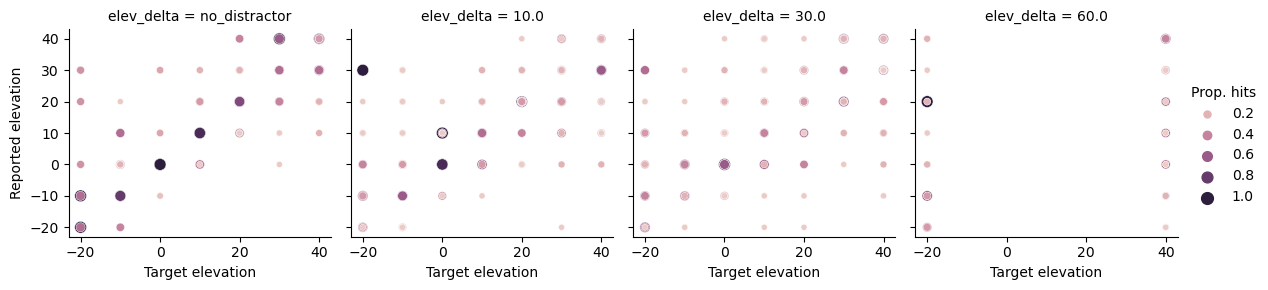

In [30]:
to_plot = results_df[(results_df.target_azimuth==0) & (results_df.azim_delta.isin([0, 'no_distractor']))].copy()
to_plot = to_plot.groupby(['target_azimuth', 'target_elevation', 'distractor_cond', 'pred_elevation', 'elev_delta', 'part_id']).count().reset_index()

for true_elev in to_plot.target_elevation.unique():
    for dist_cond in to_plot.elev_delta.unique():
        for part_id in to_plot.part_id.unique():
            elev_cond_ix = (to_plot.target_elevation == true_elev) & (to_plot.elev_delta == dist_cond) & (to_plot.part_id == part_id)
            elev_cond_trials = to_plot[elev_cond_ix]
            total_trials = elev_cond_trials.response.sum()
            to_plot.loc[elev_cond_ix, 'prop_hits'] = elev_cond_trials['response'].div(total_trials)

fig_dim = 5
# fig, axs = plt.subplots(figsize=(fig_dim,fig_dim))

g = sns.relplot(kind='scatter', data=to_plot, x='target_elevation', y='pred_elevation',
                     hue='prop_hits', size='prop_hits',
                     col='elev_delta',
                    # row='part_id',

                     height=3, aspect=1,
                    #  sizes=(5,20),
                    #  hue_norm=(.1, .5),
                    )
g.legend.set_title('Prop. hits')
g.set(xlabel='Target elevation', ylabel='Reported elevation')




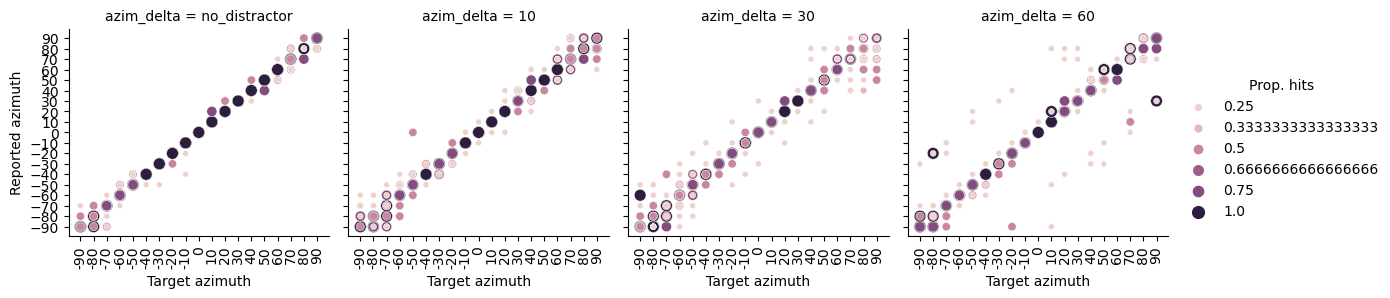

In [37]:
to_plot = results_df[(results_df.target_elevation ==0) & (results_df.elev_delta.isin([0, 'no_distractor']))].copy()
to_plot = to_plot.groupby(['target_azimuth', 'target_elevation', 'distractor_cond', 'pred_azimuth', 'azim_delta', 'part_id']).count().reset_index()

for true_elev in to_plot.target_azimuth.unique():
    for dist_cond in to_plot.azim_delta.unique():
        for part_id in to_plot.part_id.unique():
            azim_cond_ix = (to_plot.target_azimuth == true_elev) & (to_plot.azim_delta == dist_cond) & (to_plot.part_id == part_id)
            azim_cond_trials = to_plot[azim_cond_ix]
            total_trials = azim_cond_trials.response.sum()
            to_plot.loc[azim_cond_ix, 'prop_hits'] = azim_cond_trials['response'].div(total_trials)


fig_dim = 5
# fig, axs = plt.subplots(figsize=(fig_dim,fig_dim))

g = sns.relplot(kind='scatter', data=to_plot, x='target_azimuth', y='pred_azimuth',
                     hue='prop_hits', size='prop_hits',
                     col='azim_delta',
                    #  row='part_id',
                     height=3,
                    #  sizes=(5,20),
                    #  hue_norm=(.1, .5),
                    )
g.legend.set_title('Prop. hits')
g.set(xlabel='Target azimuth', ylabel='Reported azimuth', xticks=np.arange(-90, 91, 10), yticks=np.arange(-90, 91, 10))
g.set_xticklabels(labels=np.arange(-90, 91, 10), rotation=90)




In [32]:
### Get mean absolute error 
results_df['azim_error'] =  np.abs(results_df['target_azimuth'] - results_df['pred_azimuth'])
results_df['elev_error'] =  np.abs(results_df['target_elevation'] - results_df['pred_elevation']) 

In [33]:
# remove bias per participant per elevation
for part_id in results_df.part_id.unique():
    for elev in results_df.target_elevation.unique():
        elev_ix = (results_df.part_id == part_id) & (results_df.target_elevation == elev) & (results_df.distractor_cond == 'no distractor') & (results_df.target_azimuth == 0)
        all_elev_trial_ixs = (results_df.part_id == part_id) & (results_df.target_elevation == elev)
        # get participant elevation bias
        elev_bias = results_df.loc[elev_ix, 'pred_elevation'].mean() 
        results_df.loc[all_elev_trial_ixs, 'error_rel_elev_resp_bias'] = np.abs(results_df.loc[all_elev_trial_ixs, 'pred_elevation'] - elev_bias)
        # print(part_id, elev, elev_bias)

    # same for azimuth 
    for azim in results_df.target_azimuth.unique():
        azim_ix = (results_df.part_id == part_id) & (results_df.target_azimuth == azim) & (results_df.distractor_cond == 'no distractor') & (results_df.target_elevation == 0)
        all_azim_trial_ixs = (results_df.part_id == part_id) & (results_df.target_azimuth == azim)
        # get participant azimuth bias, defined as their average error in the no distractor condition
        azim_bias =  results_df.loc[azim_ix, 'pred_azimuth'].mean()
        # print(part_id, azim, azim_bias)
        results_df.loc[all_azim_trial_ixs, 'error_rel_azim_resp_bias'] = np.abs(results_df.loc[all_azim_trial_ixs, 'pred_azimuth'] - azim_bias)



In [34]:
## Group by participant 

summary_df = results_df.groupby(['part_id', 'distractor_cond', 'target_azimuth', 'target_elevation', 'azim_delta', 'elev_delta']).agg({'azim_error': 'mean',
                                                                                                                                       'elev_error': 'mean',
                                                                                                                                       'error_rel_elev_resp_bias':'mean',
                                                                                                                                       'error_rel_azim_resp_bias':'mean'}).reset_index()
# flatten columns
# summary_df.columns = ['_'.join(col).strip() for col in summary_df.columns.values]
# # remve _ in the end of each column name
# summary_df.columns = [col[:-1] if col[-1] == '_' else col for col in summary_df.columns]
summary_df

,part_id,distractor_cond,target_azimuth,target_elevation,azim_delta,elev_delta,azim_error,elev_error,error_rel_elev_resp_bias,error_rel_azim_resp_bias
0,participant_001,no distractor,-90,0,no_distractor,no_distractor,7.5,0.0,2.142857,7.50
1,participant_001,no distractor,-80,0,no_distractor,no_distractor,2.5,0.0,2.142857,3.75
2,participant_001,no distractor,-70,0,no_distractor,no_distractor,0.0,0.0,2.142857,0.00
3,participant_001,no distractor,-60,0,no_distractor,no_distractor,0.0,0.0,2.142857,0.00
4,participant_001,no distractor,-50,0,no_distractor,no_distractor,0.0,0.0,2.142857,0.00
...,...,...,...,...,...,...,...,...,...,...
764,participant_008,with distractor,80,0,30,0.0,15.0,0.0,0.000000,11.25
765,participant_008,with distractor,80,0,60,0.0,2.5,0.0,0.000000,10.00
766,participant_008,with distractor,90,0,10,0.0,5.0,0.0,0.000000,5.00
767,participant_008,with distractor,90,0,30,0.0,25.0,2.5,2.500000,23.75


Text(0.5, 1.0, 'N=8')

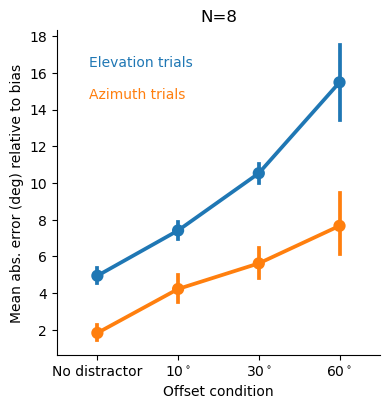

In [35]:
### Plot the error in azimuth and elevation
elev_to_plot = summary_df[(summary_df.target_azimuth == 0) & (summary_df.elev_delta!=0) ]
azim_to_plot = summary_df[(summary_df.target_elevation == 0) & (summary_df.azim_delta!=0) ]
N = summary_df.part_id.nunique()
g = sns.catplot(data=elev_to_plot,
             x='elev_delta', y='error_rel_elev_resp_bias',
            #  col='part_id',
             errorbar='se',# errstyle='bars', col
              kind='point', height=4, aspect=1)
sns.pointplot(data=azim_to_plot,
             x='azim_delta', y='error_rel_azim_resp_bias',
             color='tab:orange',
             ax=g.ax)
g.set(xlabel='Offset condition', ylabel='Mean abs. error (deg) relative to bias', )
# g.legend().remove()
# add legend with correct colors

## Add text to indicate conditions
g.ax.text(0.1, 0.9, 'Elevation trials', horizontalalignment='left', verticalalignment='center', transform=g.ax.transAxes, color='tab:blue')
g.ax.text(0.1, 0.8, 'Azimuth trials', horizontalalignment='left', verticalalignment='center', transform=g.ax.transAxes, color='tab:orange')

# update xticks
g.ax.set_xticklabels(['No distractor', '10$^\circ$', '30$^\circ$', '60$^\circ$'])
plt.title(f'N={N}')


[Text(0, 0, 'No distractor'),
 Text(1, 0, '10$^\\circ$'),
 Text(2, 0, '30$^\\circ$'),
 Text(3, 0, '60$^\\circ$')]

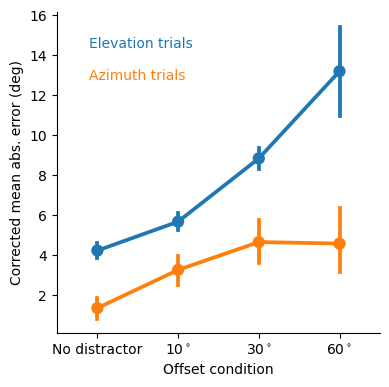

In [56]:
### Plot the error in azimuth and elevation
elev_to_plot = summary_df[(summary_df.target_azimuth == 0) & (summary_df.elev_delta!=0) ]
azim_to_plot = summary_df[(summary_df.target_elevation == 0) & (summary_df.azim_delta!=0) ]

g = sns.catplot(data=elev_to_plot,
             x='elev_delta', y='scaled_elev_error_mean',
            #  col='part_id',
             errorbar='se',# errstyle='bars', col
              kind='point', height=4, aspect=1)
sns.pointplot(data=azim_to_plot,
             x='azim_delta', y='scaled_azim_error_mean',
             color='tab:orange',
             ax=g.ax)
g.set(xlabel='Offset condition', ylabel='Corrected mean abs. error (deg)')
# g.legend().remove()
# add legend with correct colors

## Add text to indicate conditions
g.ax.text(0.1, 0.9, 'Elevation trials', horizontalalignment='left', verticalalignment='center', transform=g.ax.transAxes, color='tab:blue')
g.ax.text(0.1, 0.8, 'Azimuth trials', horizontalalignment='left', verticalalignment='center', transform=g.ax.transAxes, color='tab:orange')

# update xticks
g.ax.set_xticklabels(['No distractor', '10$^\circ$', '30$^\circ$', '60$^\circ$'])



[Text(0.5, 25.722222222222214, 'Azimuth difference'),
 Text(510.3244949494949, 0.5, 'Corrected mean abs. error (deg)'),
 (-1.0, 20.0)]

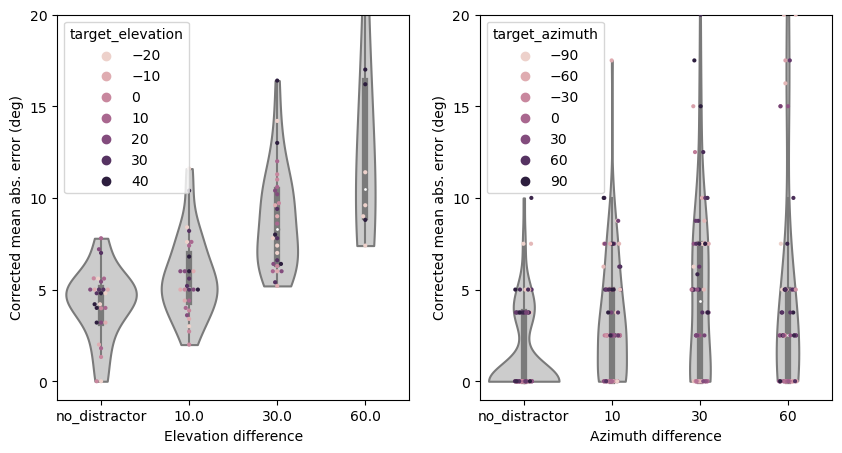

In [14]:
elev_to_plot = summary_df[(summary_df.target_azimuth == 0) & (summary_df.elev_delta!=0) ]
azim_to_plot = summary_df[(summary_df.target_elevation == 0) & (summary_df.azim_delta!=0) ]

fig, axs = plt.subplots(1, 2, figsize=(10, 5))

g = sns.violinplot(data=elev_to_plot, x="elev_delta", y="scaled_elev_error_mean", color = '0.8', cut=0, height=4, ax=axs[0])
sns.swarmplot(data=elev_to_plot, x="elev_delta", y="scaled_elev_error_mean", hue="target_elevation", size=3, ax=axs[0])

g.set(xlabel='Elevation difference', ylabel='Corrected mean abs. error (deg)', yticks=np.arange(0, 21, 5), ylim=(-1, 20))
# axs[0].legend().remove() # set_title('Elevation difference')



g = sns.violinplot(data=azim_to_plot, x="azim_delta", y="scaled_azim_error_mean", color = '0.8',  cut=0, height=4, ax=axs[1])
sns.stripplot(data=azim_to_plot, x="azim_delta", y="scaled_azim_error_mean", hue="target_azimuth", size=3, ax=axs[1])
g.set(xlabel='Azimuth difference', ylabel='Corrected mean abs. error (deg)', yticks=np.arange(0, 21, 5), ylim=(-1, 20))
# axs[1].legend().remove() # set_title('azimation difference')

### Sanity/detail check plots

In [22]:
azim_to_plot

,part_id,distractor_cond,target_azimuth,target_elevation,azim_delta,elev_delta,azim_error_mean,azim_error_std,elev_error_mean,elev_error_std,scaled_elev_error_mean,scaled_elev_error_std,scaled_azim_error_mean,scaled_azim_error_std
0,participant_001,no distractor,-90,0,no_distractor,no_distractor,7.5,9.574271,0.0,0.0,2.142857,0.0,7.50,4.082483
1,participant_001,no distractor,-80,0,no_distractor,no_distractor,2.5,5.000000,0.0,0.0,2.142857,0.0,3.75,2.500000
2,participant_001,no distractor,-70,0,no_distractor,no_distractor,0.0,0.000000,0.0,0.0,2.142857,0.0,0.00,0.000000
3,participant_001,no distractor,-60,0,no_distractor,no_distractor,0.0,0.000000,0.0,0.0,2.142857,0.0,0.00,0.000000
4,participant_001,no distractor,-50,0,no_distractor,no_distractor,0.0,0.000000,0.0,0.0,2.142857,0.0,0.00,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
387,participant_004,with distractor,80,0,30,0.0,7.5,15.000000,0.0,0.0,0.714286,0.0,7.50,15.000000
388,participant_004,with distractor,80,0,60,0.0,2.5,5.000000,0.0,0.0,0.714286,0.0,2.50,5.000000
389,participant_004,with distractor,90,0,10,0.0,10.0,8.164966,0.0,0.0,0.714286,0.0,10.00,8.164966
390,participant_004,with distractor,90,0,30,0.0,7.5,15.000000,0.0,0.0,0.714286,0.0,7.50,15.000000


<AxesSubplot:xlabel='target_azimuth', ylabel='scaled_azim_error_mean'>

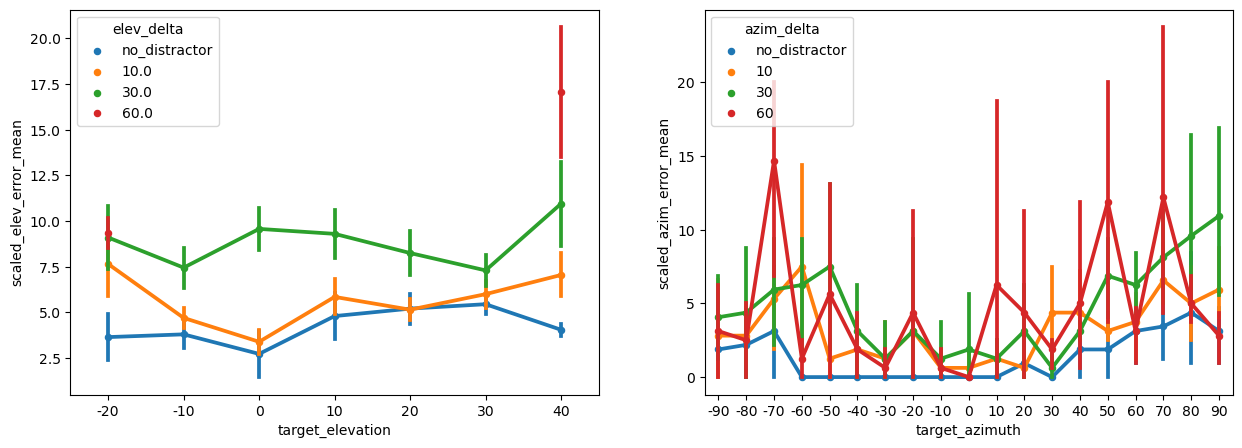

In [21]:
### Plot the error in azimuth and elevation
elev_to_plot = summary_df[(summary_df.target_azimuth == 0) & (summary_df.elev_delta!=0) ]
azim_to_plot = summary_df[(summary_df.target_elevation == 0) & (summary_df.azim_delta!=0) ]

fig, axs = plt.subplots(1, 2, figsize=(15, 5))
g = sns.pointplot(data=elev_to_plot,
             x='target_elevation', y='scaled_elev_error_mean',
             hue='elev_delta',
             ax = axs[0],
             markers='.',
             errorbar='se',# errstyle='bars',
            )

sns.pointplot(data=azim_to_plot,
             x='target_azimuth', y='scaled_azim_error_mean',
            hue='azim_delta',
             ax = axs[1],
            markers='.',


            #  color='tab:orange',
        )
# g.set(xlabel='Offset condition', ylabel='Corrected mean abs. error (deg)')
# g.legend().remove()
# add legend with correct colors

# ## Add text to indicate conditions
# g.ax.text(0.1, 0.9, 'Elevation trials', horizontalalignment='left', verticalalignment='center', transform=g.ax.transAxes, color='tab:blue')
# g.ax.text(0.1, 0.8, 'Azimuth trials', horizontalalignment='left', verticalalignment='center', transform=g.ax.transAxes, color='tab:orange')

# # update xticks
# g.ax.set_xticklabels(['No distractor', '10$^\circ$', '30$^\circ$', '60$^\circ$'])



[Text(0, 0, 'No distractor'),
 Text(1, 0, '10$^\\circ$'),
 Text(2, 0, '30$^\\circ$'),
 Text(3, 0, '60$^\\circ$')]

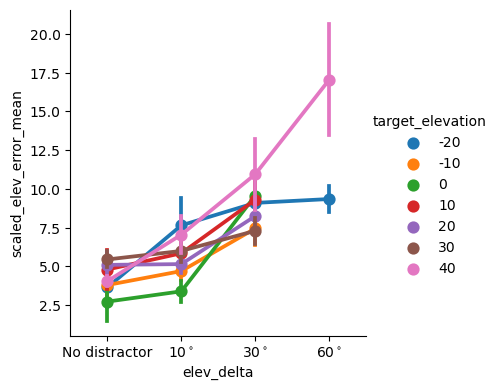

In [107]:
### Plot the error in azimuth and elevation
elev_to_plot = summary_df[(summary_df.target_azimuth == 0) & (summary_df.elev_delta!=0) ]

g = sns.catplot(data=elev_to_plot,
             x='elev_delta', y='scaled_elev_error_mean',
             hue='target_elevation',
             errorbar='se',# errstyle='bars',
              kind='point', height=4, aspect=1)

# update xticks
g.ax.set_xticklabels(['No distractor', '10$^\circ$', '30$^\circ$', '60$^\circ$'])



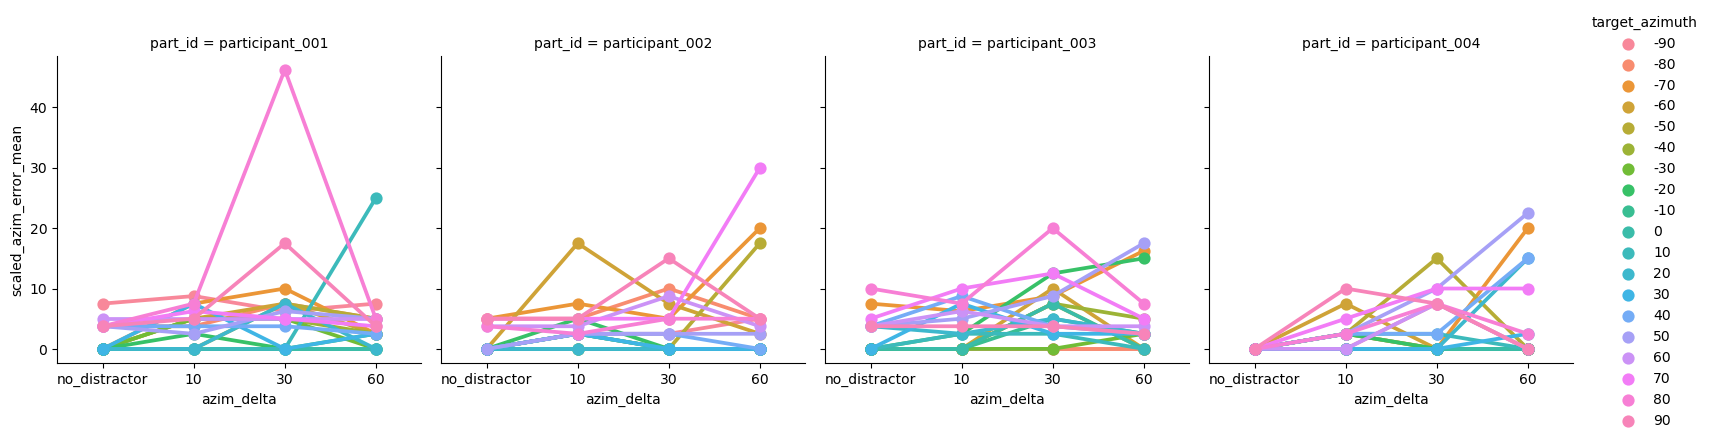

In [108]:
### Plot the error in azimuth and elevation
azim_to_plot = summary_df[(summary_df.target_elevation == 0) & (summary_df.azim_delta!=0) ]

g = sns.catplot(data=azim_to_plot,
             x='azim_delta', y='scaled_azim_error_mean',
             hue='target_azimuth', col='part_id',
             errorbar='se',# errstyle='bars',
              kind='point', height=4, aspect=1)

# update xticks
# g.ax.set_xticklabels(['No distractor', '10$^\circ$', '30$^\circ$', '60$^\circ$'])

